After running the cell below, you will be prompted to authorize this notebook to access your Google Drive. Once authorized, your Drive content will be accessible under `/content/drive/My Drive/`.

In [ ]:
import os
import torch

# Detect environment (Colab vs local/GitHub)
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

    # Optional: only use Drive if you *really* need it
    BASE_PATH = "/content/drive/MyDrive/bimodal-emotion-project"
else:
    # When cloned from GitHub
    BASE_PATH = os.path.abspath(".")

os.chdir(BASE_PATH)

print("Current directory:", os.getcwd())
print("Files:", os.listdir())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Mounted at /content/drive
current directory is : /content/drive/My Drive/Bimodal Emotional Context Tagger project


['dev_sent_emo.csv',
 'test_sent_emo.csv',
 'train_sent_emo.csv',
 'train_splits_audio',
 'dev_splits_audio',
 'test_splits_audio']

Loading the .csv files from the MELD dataset

In [ ]:
!pip install -r requirements.txt
import pandas as pd
from ftfy import fix_text

train_df = pd.read_csv("train_sent_emo.csv")
val_df = pd.read_csv("dev_sent_emo.csv")
test_df = pd.read_csv("test_sent_emo.csv")

for df in (train_df, val_df, test_df):
  df["Utterance"] = df["Utterance"].apply(fix_text)

Index(['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID',
       'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime'],
      dtype='object')
Emotion
neutral     4710
joy         1743
surprise    1205
anger       1109
sadness      683
disgust      271
fear         268
Name: count, dtype: int64


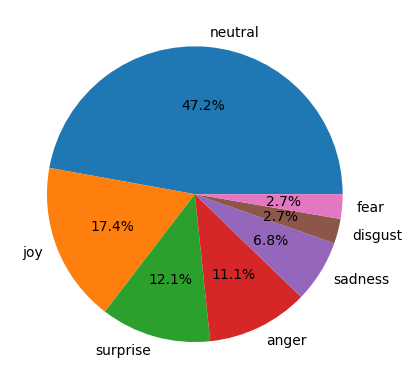

In [ ]:
# get a feel for the structure and distribution of labels in the dataset
from matplotlib import pyplot as plt
import numpy as np

print(train_df.columns)
print(train_df["Emotion"].value_counts())

plt.pie(train_df["Emotion"].value_counts(), labels=train_df["Emotion"].value_counts().index, autopct='%1.1f%%')
plt.show()

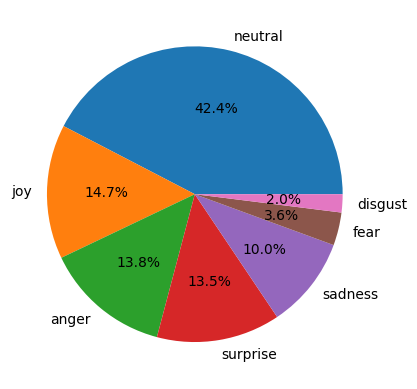

In [ ]:
plt.pie(val_df["Emotion"].value_counts(), labels=val_df["Emotion"].value_counts().index, autopct='%1.1f%%')
plt.show()

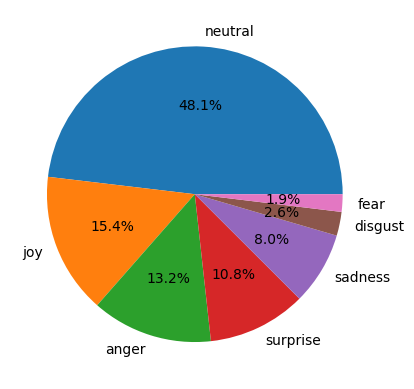

In [ ]:
plt.pie(test_df["Emotion"].value_counts(), labels=test_df["Emotion"].value_counts().index, autopct='%1.1f%%')
plt.show()

Adding a numeric label for each emotion to give a clear ID for each one

In [ ]:
emotion_map = {
    'neutral': 0,
    'surprise': 1,
    'fear': 2,
    'sadness': 3,
    'joy': 4,
    'disgust': 5,
    'anger': 6
}

def encode_labels(df):
    df["label"] = df["Emotion"].map(emotion_map)
    return df

train_df = encode_labels(train_df)
val_df = encode_labels(val_df)
test_df = encode_labels(test_df)

Tokenize the utterances so they can be parsed by the Transformer model

In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize(df):
    return tokenizer(
        df["Utterance"].tolist(),
        truncation=True,
        padding=True,
        max_length=128   # IMPORTANT (don’t use 512, makes the model slower)
    )

train_encodings = tokenize(train_df)
val_encodings = tokenize(val_df)
test_encodings = tokenize(test_df)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Define a dataset class for PyTorch to use to interact with the dataset

In [ ]:
import torch
from torch.utils.data import Dataset

class MELDDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = MELDDataset(train_encodings, train_df["label"])
val_dataset = MELDDataset(val_encodings, val_df["label"])
test_dataset = MELDDataset(test_encodings, test_df["label"])

# to define custom label weights (accounting for class imbalance in the loss function)
class_weights = torch.tensor([4.0, 15.0, 15.0, 3.0, 1.0, 6.0, 3.0])

Import the model

In [ ]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=7
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Define training metrics and evaluation metrics (accuracy, f1 score)

In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import f1_score, accuracy_score
from transformers import Trainer
import torch.nn as nn
import os

# os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    # Changed output_dir to a local temporary path to avoid saving to Google Drive
    output_dir="/tmp/checkpoints",

    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,

    eval_strategy="epoch",   # or evaluation_strategy depending on version
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,

    weight_decay=0.05,
    warmup_steps=100,

    fp16=True,
    logging_steps=25,
    logging_strategy="steps",
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    class_weights.to(logits.device)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

# custom trainer to use our "class_weights"
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

Run the training loop

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.019275,1.080227,0.577096,0.325533,0.511206
2,1.114265,1.013546,0.560866,0.399674,0.542121
3,0.834662,1.030094,0.569883,0.389346,0.524592
4,0.784649,1.057488,0.591524,0.436561,0.565949
5,0.562109,1.130169,0.605050,0.457145,0.581883
6,0.511831,1.193729,0.597836,0.460692,0.580674
7,0.434037,1.247966,0.602344,0.433621,0.579320


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4375, training_loss=0.7976305134364536, metrics={'train_runtime': 623.9186, 'train_samples_per_second': 160.101, 'train_steps_per_second': 10.017, 'total_flos': 3305951762454600.0, 'train_loss': 0.7976305134364536, 'epoch': 7.0})

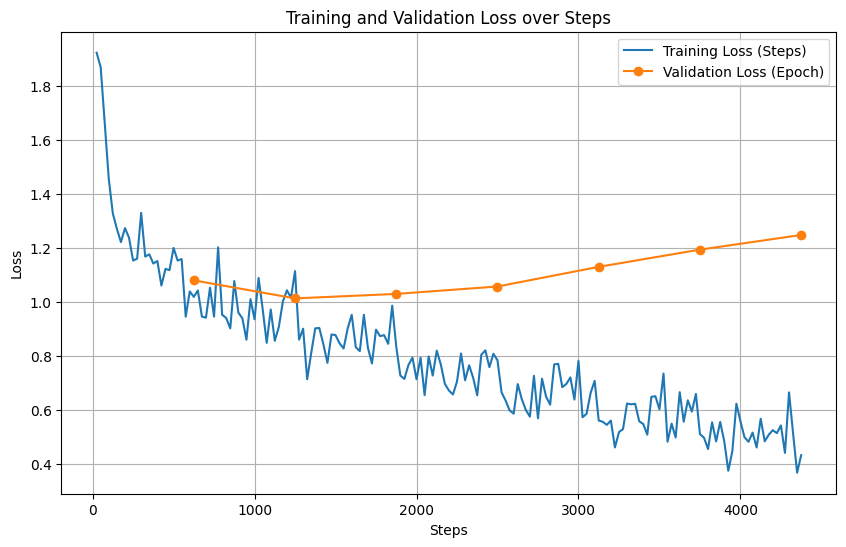

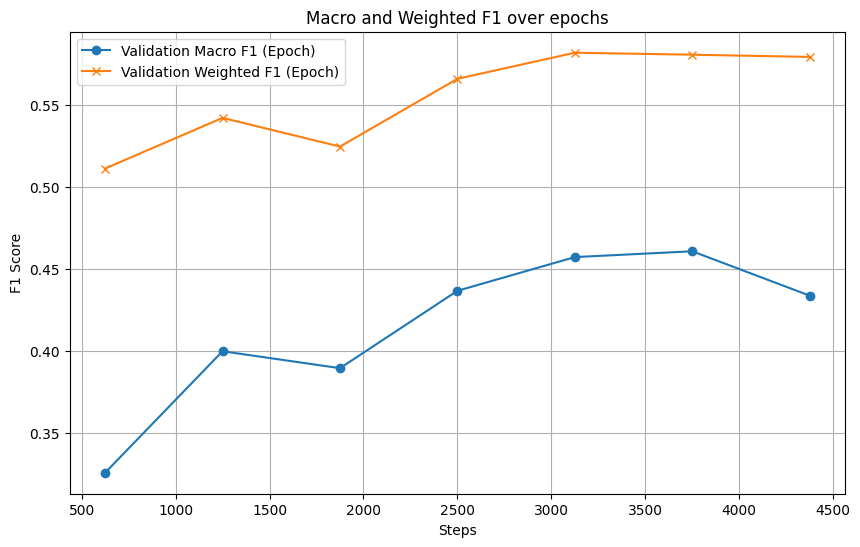

In [ ]:
import matplotlib.pyplot as plt

# Extract logs
history = trainer.state.log_history

# Filter for training loss (logged every 'logging_steps')
train_data = [x for x in history if 'loss' in x]
train_loss = [x['loss'] for x in train_data]
train_steps = [x['step'] for x in train_data]

# Filter for evaluation loss (logged every 'eval_strategy' / epoch)
eval_data = [x for x in history if 'eval_loss' in x]
eval_loss = [x['eval_loss'] for x in eval_data]
eval_steps = [x['step'] for x in eval_data]

# Plotting Loss
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label='Training Loss (Steps)')
plt.plot(eval_steps, eval_loss, label='Validation Loss (Epoch)', marker='o')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

# Plotting F1 Scores
plt.figure(figsize=(10, 6))
plt.plot(eval_steps, [x['eval_macro_f1'] for x in eval_data], label='Validation Macro F1 (Epoch)', marker='o')
plt.plot(eval_steps, [x['eval_weighted_f1'] for x in eval_data], label='Validation Weighted F1 (Epoch)', marker='x')
plt.xlabel('Steps')
plt.ylabel('F1 Score')
plt.title('Macro and Weighted F1 over epochs')
plt.legend()
plt.grid(True)
plt.show()

Run the evaluation on the test set

In [ ]:
trainer.evaluate(test_dataset)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.434037,1.166065,7,0.609195,0.425595,0.595829


{'eval_loss': 1.1660646200180054,
 'eval_accuracy': 0.6091954022988506,
 'eval_macro_f1': 0.42559531228182096,
 'eval_weighted_f1': 0.5958294829273111}

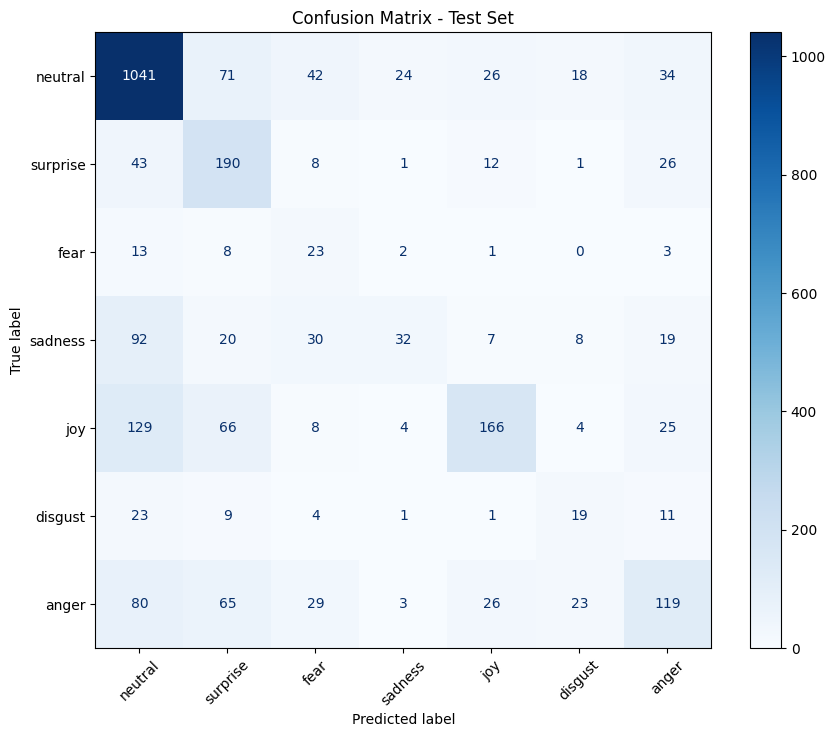

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions from the test set
predictions = trainer.predict(test_dataset)
y_preds = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Create confusion matrix
cm = confusion_matrix(y_true, y_preds)
labels = sorted(emotion_map, key=emotion_map.get)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix - Test Set')
plt.show()

In [ ]:
from sklearn.metrics import f1_score

true_labels = test_df['label'].values
per_class_f1 = f1_score(true_labels, y_preds, average=None)

print("Per-Class F1 Scores:")
for emotion, score in zip(emotion_map.keys(), per_class_f1):
    print(f"{emotion:10}: {score:.4f}")

Per-Class F1 Scores:
neutral   : 0.7777
surprise  : 0.5352
fear      : 0.2371
sadness   : 0.2327
joy       : 0.5179
disgust   : 0.2695
anger     : 0.4089
